# Initial Data Exploration

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.executable

'C:\\Users\\AUCLAIR\\Documents\\Projet_Data_Pro_3\\venv\\Scripts\\python.exe'

In [2]:
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")

## Analysis of Orders

In [3]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [4]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [5]:
doublons_orders = orders.duplicated(subset = 'order_id', keep = False)
orders[doublons_orders]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


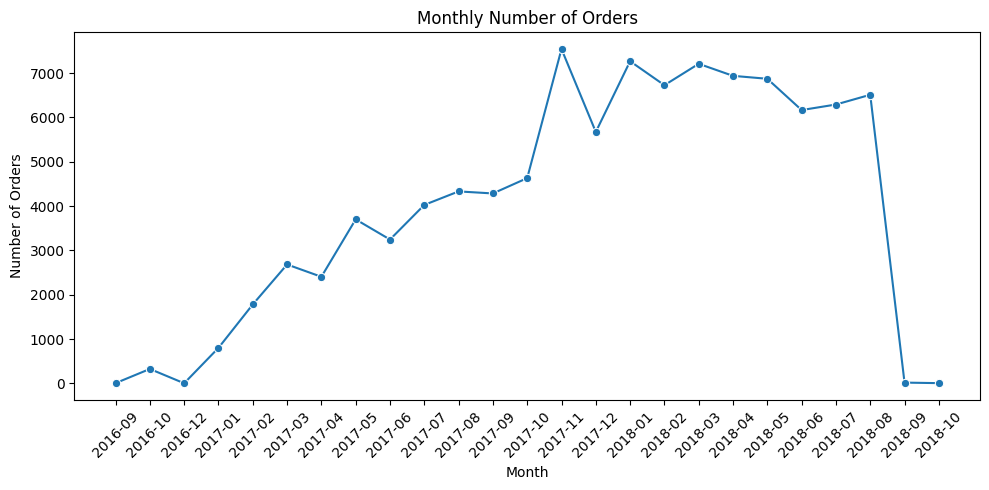

In [15]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders.groupby('year_month').size().reset_index(name='order_count')
monthly_orders['year_month'] = monthly_orders['year_month'].astype(str)

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_orders, x='year_month', y='order_count', marker='o')

plt.xticks(rotation=45)
plt.title("Monthly Number of Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

## Analysis of customers

In [7]:
customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [8]:
customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [9]:
doublons_customers = customers.duplicated(subset = 'customer_id', keep = False)
customers[doublons_customers]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


In [10]:
customer_orders = orders.groupby('customer_id').size()

customer_orders.value_counts().head(10)

1    99441
Name: count, dtype: int64

## Analysis of order_items

In [11]:
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [12]:
order_items.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [13]:
doublons_order_items = order_items.duplicated(subset = 'order_item_id', keep = False)
order_items[doublons_order_items]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


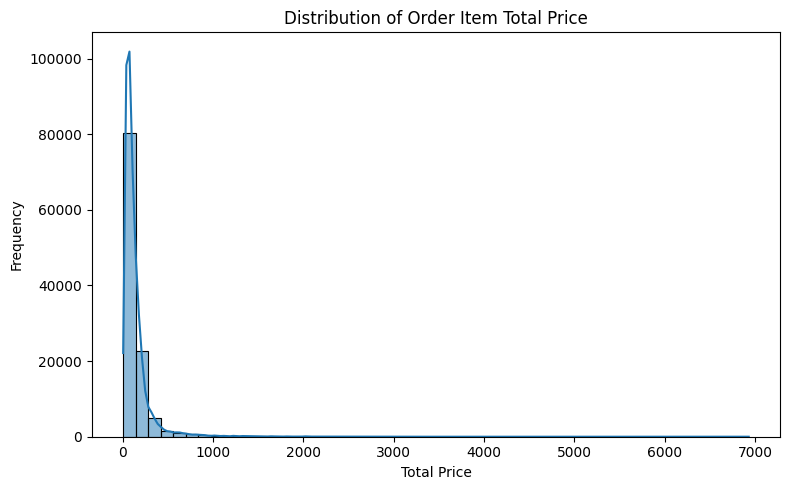

In [16]:
order_items['total_price'] = order_items['price'] + order_items['freight_value']

plt.figure(figsize=(8,5))
sns.histplot(order_items['total_price'], bins=50, kde=True)

plt.title("Distribution of Order Item Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [17]:
order_items[['price', 'freight_value']].corr()

,price,freight_value
price,1.000000,0.414204
freight_value,0.414204,1.000000


### Key Observations

- The distribution of order item total price is highly concentrated, with most values ranging between 0 and 400, indicating a relatively low average basket size.

- There is a moderate positive correlation (0.41) between product price and freight value, suggesting that more expensive items tend to have higher shipping costs.

- The number of orders shows an overall increasing trend over time, reflecting business growth. However, a sharp drop is observed in August and September 2018, which may indicate incomplete data or an external anomaly.